## Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output

from simple_database import simple_database as sdb

from aq_gnome import (
    Data_Handler,
    plot_periodic_table_with_values, get_col_dict_for_atoms,
    Stable_Entries, Stability_Criteria, get_simplified_df,
    atoms_from_db, Compound_HHI_scores, sys_in_MP_db,
)
from aq_gnome.grand_potential import (GrandPotentialAnalyzer, delta_mu_O, MPCache, ResultsCache)
from aq_gnome.grand_potential._shomate import S_O2, dH0_O2

col_list = sns.color_palette("tab10", 100)

MP_API_KEY = os.environ.get("MP_API_KEY", None)

## Grand Potential Analyzer - Code base DEMO

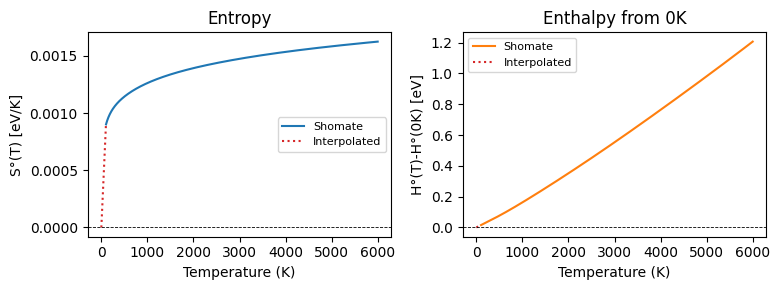

In [39]:
T_range = np.linspace(0, 6000, 2000)
Ss = [S_O2(T, eV=True)   for T in T_range]
Hs = [dH0_O2(T, eV=True) for T in T_range]

# Split at the 100 K interpolation boundary
mask_interp  = T_range <= 100
mask_shomate = T_range >= 100  # overlap at 100 K keeps segments connected

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

Ss_arr = np.array(Ss)
Hs_arr = np.array(Hs)

ax1.plot(T_range[mask_shomate], Ss_arr[mask_shomate], lw=1.5, color='tab:blue',   label='Shomate')
ax1.plot(T_range[mask_interp],  Ss_arr[mask_interp],  lw=1.5, color='tab:red', ls=':', label='Interpolated')
ax1.axhline(0, color='k', lw=0.6, ls='--')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('S°(T) [eV/K]')
ax1.set_title('Entropy')
ax1.legend(fontsize=8)

ax2.plot(T_range[mask_shomate], Hs_arr[mask_shomate], lw=1.5, color='tab:orange', label='Shomate')
ax2.plot(T_range[mask_interp],  Hs_arr[mask_interp],  lw=1.5, color='tab:red', ls=':', label='Interpolated')
ax2.axhline(0, color='k', lw=0.6, ls='--')
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('H°(T)-H°(0K) [eV]')
ax2.set_title('Enthalpy from 0K')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

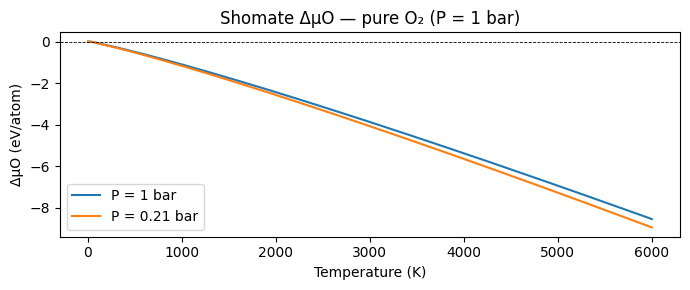

ΔμO(298 K, P=1.0) = -0.2720 eV/atom
ΔμO(298 K, P=0.21) = -0.2920 eV/atom  (air)


In [40]:
T_range = np.linspace(0, 6000, 200)
dmu_vals = [delta_mu_O(T, P_O2=1.0) for T in T_range]
dmu_vals_air = [delta_mu_O(T, P_O2=0.21) for T in T_range]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(T_range, dmu_vals, lw=1.5, label='P = 1 bar')
ax.plot(T_range, dmu_vals_air, lw=1.5, label='P = 0.21 bar')
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('ΔμO (eV/atom)')
ax.set_title('Shomate ΔμO — pure O₂ (P = 1 bar)')
ax.legend()
plt.tight_layout()
plt.show()

# Spot-check: at T=298K should be close to JANAF reference value ~−0.27 eV
print(f"ΔμO(298 K, P=1.0) = {delta_mu_O(298.15, P_O2=1.0):.4f} eV/atom")
print(f"ΔμO(298 K, P=0.21) = {delta_mu_O(298.15, P_O2=0.21):.4f} eV/atom  (air)")

## Database setup

In [41]:
dir_of_data = None

dh = Data_Handler(
    solid_filter=True,
    gga_only=False,
    path_to_data_directory=dir_of_data,
)

db = sdb('processed_GNoME_entries_pp_corr.db', make_new_db=False)

## Element filtering

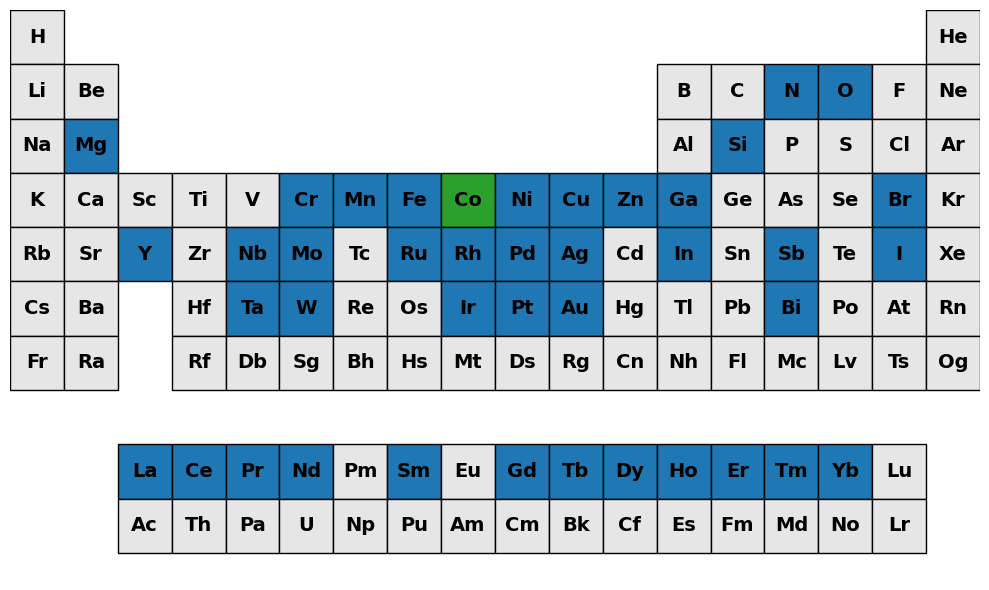

In [42]:
radioactive_elements = ['Tc',  'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs',
                        'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv',
                        'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np',
                        'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md',
                        'No', 'Lr', 'Po', 'At', 'Rn']

reactive_with_water_elements = ['Li', 'Na', 'K', 'Rb', 'Cs', 'Fr', 'Ca', 'Ba']
toxic_elements = ['Tl', 'Pb', 'As', 'Cd', 'Hg']

avail_chemicals = ['Ag', 'Bi', 'Br', 'Ce', 'Co', 'Cu', 'Dy', 'Er', 'Fe',
                   'Ga', 'Ho', 'I', 'In', 'In', 'La', 'Mg', 'Mn', 'Mo', 'Nd',
                   'Ni', 'Pd', 'Pr', 'Pt', 'Rh', 'Ru', 'Sb', 'Sm', 'Tb', 'Tm',
                   'Y', 'Zn', 'Nb', 'Au', 'W', 'Cr', 'Gd', 'Ta', 'Yb', 'Va'] + ['O', 'N'] + ['Ir', 'Si']

elements_to_exclude = radioactive_elements + toxic_elements + reactive_with_water_elements + ['Br', 'C', 'F', 'Se', 'Te', 'B', 'P', 'S', 'Cl']
elements_which_must_be_included = ['Co']

plot_periodic_table_with_values(
    get_col_dict_for_atoms(elements_exclusively_allowed=avail_chemicals,
                           elements_to_include=elements_which_must_be_included)
)

In [43]:
dh.restore_df()
dh.remove_entries_not_consisting_exclusively_of_elements(avail_chemicals)
dh.remove_entries_without_elements(elements_which_must_be_included, True)

Removed all entries not consisting exclusively of: Ag, Bi, Br, Ce, Co, Cu, Dy, Er, Fe, Ga, Ho, I, In, In, La, Mg, Mn, Mo, Nd, Ni, Pd, Pr, Pt, Rh, Ru, Sb, Sm, Tb, Tm, Y, Zn, Nb, Au, W, Cr, Gd, Ta, Yb, Va, O, N, Ir, Si . Number of entries removed: 427635 Number of entries left: 101336 which is 19.16% of total GNoME database
Removed all entries not containing all of the following elements: Co .Number of entries removed: 86215 Number of entries left: 15121 which is 2.86% of total GNoME database


## PBX stability criteria

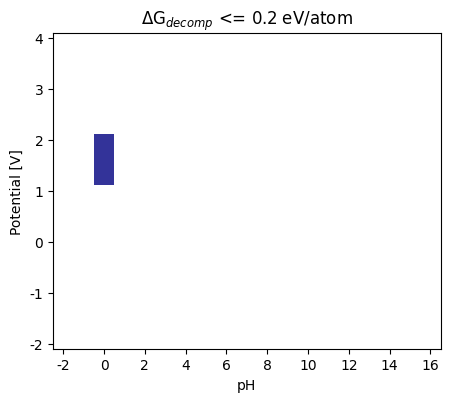

In [44]:
SCS = [
    Stability_Criteria(pHs=[0], Us=[1.2, 2], decomposition_threshold=0.2),
]

for sc in SCS:
    sc.visualize()

In [45]:
se = Stable_Entries(dh, SCS)
df = se.get_stable_df()

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


100%|██████████| 15121/15121 [00:13<00:00, 1108.30it/s]

Found 69 stable entries given the stability criteria.


In [46]:
df = df[df['average_HHI_P_excluding_O_H'] < 3500]
df = df[df['max_HHI_P'] <= 5500]
print(f"{len(df)} candidates after HHI filtering")
df

19 candidates after HHI filtering


,"max_dG_U[1.2,2]_pH0",Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,Space Group,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
4690,0.14,Br6Co1Mn1O18,02392b0de5,MnCo(BrO3)6,"[O, Mn, Co, Br]",26,405.0287,3.6131,3,P3,...,gs://surface-design/input/round_6_4/1e_3_med_0...,GGA_02392b0de5,GGA_02392b0de5,0.004115,1288.0,2112.0,3062.0,5738.0,3300.0,6900.0
11820,0.12,Br8Co3Ni1O24,05b4f17fc3,Co3Ni(BrO3)8,"[O, Co, Ni, Br]",36,548.4026,3.8113,1,P1,...,gs://surface-design/input/round_6_4/1e_3_med_0...,GGA_05b4f17fc3,GGA_05b4f17fc3,0.003403,1353.0,2133.0,3058.0,5400.0,3300.0,6900.0
59014,0.13,Br8Co3Mg1O24,1c8c3d6b0a,MgCo3(BrO3)8,"[O, Mg, Co, Br]",36,548.8152,3.7044,1,P1,...,gs://crystal-design/output/borg/round_3_4/1e_3...,GGA_1c8c3d6b0a,r2S_1c8c3d6b0a,0.003206,1472.0,2106.0,3417.0,5317.0,5300.0,6900.0
81679,0.18,Bi4Co1Cu4Mn3O20,277f124627,Mn3CoCu4(BiO5)4,"[O, Mn, Co, Cu, Bi]",32,379.3577,7.1517,2,P2,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_277f124627,GGA_277f124627,0.932702,1422.0,1503.0,2958.0,3175.0,5300.0,6000.0
97127,0.14,Br8Co1Mn2O24Zn1,2efc7fc470,Mn2ZnCo(BrO3)8,"[O, Mn, Co, Zn, Br]",36,574.6663,3.6335,1,P1,...,gs://crystal-design/output/borg/round_5_5/1e_3...,GGA_2efc7fc470,GGA_2efc7fc470,0.004341,1286.0,2094.0,2858.0,5283.0,3300.0,6900.0
135663,0.14,Br8Co2Mg1O24Zn1,4195f01baf,MgZnCo2(BrO3)8,"[O, Mg, Co, Zn, Br]",36,553.8877,3.6899,1,P1,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_4195f01baf,GGA_4195f01baf,0.784907,1431.0,2083.0,3292.0,5250.0,5300.0,6900.0
150418,0.13,Co3Mo6O24Zn3,48bbcb793d,ZnCo(MoO4)2,"[O, Co, Zn, Mo]",36,544.9272,4.0609,1,P1,...,gs://crystal-design/output/borg/round_2_mo_4/1...,GGA_48bbcb793d,Not computed,0.283540,1125.0,1600.0,2375.0,3800.0,3100.0,5300.0
175964,0.15,Br8Co1Mg2O24Zn1,55273a76b2,Mg2ZnCo(BrO3)8,"[O, Mg, Co, Zn, Br]",36,555.8878,3.5732,1,P1,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_55273a76b2,GGA_55273a76b2,0.935822,1492.0,2022.0,3475.0,5067.0,5300.0,6900.0
235007,0.16,Br8Co1Ni3O24,71bff41d26,CoNi3(BrO3)8,"[O, Co, Ni, Br]",36,535.4672,3.9019,1,P1,...,gs://surface-design/input/round_6_4/1e_3_med_0...,GGA_71bff41d26,GGA_71bff41d26,0.003319,1236.0,2067.0,2708.0,5200.0,3300.0,6900.0
243896,0.13,Br8Co3O24Zn1,761976f3ea,ZnCo3(BrO3)8,"[O, Co, Zn, Br]",36,549.0071,3.8274,1,P1,...,gs://crystal-design/output/borg/round_3_4/1e_3...,GGA_761976f3ea,GGA_761976f3ea,0.003213,1369.0,2144.0,3108.0,5433.0,3300.0,6900.0


## Grand Potential Analysis

### Initialise GrandPotentialAnalyzer

In [ ]:
import os
from aq_gnome.grand_potential import list_result_stores

T_range = np.linspace(0, 6000, 300)
os.makedirs("results", exist_ok=True)

# Which result stores already exist, and what physics is in each? (one .h5 per config)
display(list_result_stores("results"))

STORE = "results/demo_GGA.h5"                              # name a store per physics config
cache = MPCache(path="mp_cache.db", api_key=MP_API_KEY)    # SHARED MP download cache (config-independent)

if os.path.exists(STORE):
    # Attach to the existing store and ADOPT its physics — only ever appends, never resets.
    results  = ResultsCache(STORE)
    analyzer = GrandPotentialAnalyzer.from_results_cache(results, cache, db, gnome_df=df)
else:
    # First time: create the store (force=True) under the config below. To change a physics knob,
    # use a NEW store name (or it refuses to overwrite unless force=True) — so you never lose results.
    results  = ResultsCache(STORE, force=True)
    analyzer = GrandPotentialAnalyzer(
        cache=cache, gnome_db=db, gnome_df=df,
        include_gnome_competitors=False,   # True = add all GNoME-in-system phases (deduped vs MP)
        mixing='GGA',                      # 'GGA+r2SCAN' also available
        P_O2=1.0,                          # pure O2; 0.21 = air
        si_reference=None,                 # None = Si not opened; 'SiO2' or 'Si' to open Si
        T_values=T_range,
        results_cache=results,
    )

print("physics:", analyzer.config)

### Single-entry smoke test

In [86]:
def plot_stability_decomp(T_arr, E_arr, decomp_list, formula, ax=None):
    """Plot E above hull vs T with line segments colored by decomp products.

    Each contiguous block of identical decomposition-product sets gets a unique
    color. Labels are placed at the top of the axes, centered in each block.
    Vertical dotted lines mark regime transitions.

    Parameters
    ----------
    T_arr : np.ndarray  Temperatures in Kelvin.
    E_arr : np.ndarray  E above hull in eV/atom.
    decomp_list : list of dict  One {formula: fraction} dict per T point.
    formula : str  Title for the axes.
    ax : matplotlib Axes, optional.  Created if not supplied.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))

    T_C = T_arr - 273.15
    N = len(T_arr)

    # --- 1. Decomp signature per point (frozenset of formula keys) ---
    sigs = [frozenset(d.keys()) for d in decomp_list]

    # --- 2. Assign one color per unique signature (first-appearance order) ---
    palette = plt.cm.tab10.colors
    unique_sigs = list(dict.fromkeys(sigs))
    sig_color = {sig: palette[i % len(palette)] for i, sig in enumerate(unique_sigs)}

    # --- 3. Find contiguous regions ---
    regions = []
    i_s = 0
    for i in range(1, N):
        if sigs[i] != sigs[i_s]:
            regions.append((i_s, i - 1, sigs[i_s]))
            i_s = i
    regions.append((i_s, N - 1, sigs[i_s]))

    # --- 4. Plot colored segments ---
    for i_s, i_e, sig in regions:
        end = min(i_e + 2, N)  # include one extra point so segments connect
        ax.plot(T_C[i_s:end], E_arr[i_s:end], '-', color=sig_color[sig], lw=2)

    # --- 5. Reference line, transitions, and labels ---
    ax.axhline(0, color='k', ls='--', lw=0.7, alpha=0.6)

    trans = ax.get_xaxis_transform()  # x: data coords, y: axes fraction

    for i, (i_s, i_e, sig) in enumerate(regions):
        color = sig_color[sig]
        T_mid = (T_C[i_s] + T_C[i_e]) / 2
        label = ' + '.join(sorted(sig))
        # rotation = 30 if len(label) > 30 else 0

        ax.text(T_mid, 0.97, label, transform=trans, color=color,
                ha='center', va='top', fontsize=8, fontweight='bold',
                rotation=30)

        if i > 0:  # transition line (not at left edge)
            ax.axvline(T_C[i_s], color='gray', ls=':', lw=0.9, alpha=0.6)

    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('E above hull (eV/atom)')
    ax.set_title(formula)
    return ax

In [ ]:
row0 = df.iloc[-1]

res = analyzer.compute_one(row0['MaterialId'], return_decomp=True)

# print(f"Formula : {row0['Reduced Formula']}")
# print(f"T shape : {res.T_values.shape},  E shape: {res.E_above_hull.shape}")
# print(f"MP-substituted: {res.mp_substituted}")

plot_stability_decomp(res.T_values, res.E_above_hull, res.decomp, row0['Reduced Formula'])
plt.tight_layout()
# plt.xlim(-300, 1000)
# plt.show()

### Full batch run

In [ ]:
data = []
from tqdm import tqdm

for idx in tqdm(range(len(df)), total=len(df)):
    row = df.iloc[idx]
    res = analyzer.compute_one(row['MaterialId'], return_decomp=True)
    T_C = res.T_values - 273.15
    data.append((T_C, res.E_above_hull, res.decomp, row['Reduced Formula']))

In [ ]:
# --- Load & sort from the results store (no recompute) ---
# After the batch above, every curve is in `results`. Reload them all and filter post-hoc — this is
# the "run once, re-sort fast" payoff: changing the criterion below never recomputes a curve.
ids, E, mp_sub = results.load_curves()
T_C = results.T_grid - 273.15

# Example criterion: dips below the MP hull (E < 0) anywhere in the 450-550 °C window.
window = (T_C >= 450) & (T_C <= 550)
below_hull = E[:, window].min(axis=1) < 0.0
print(f"{below_hull.sum()} / {len(ids)} candidates dip below the hull in 450-550 °C")

# The store keeps only ids + curves (+ mp_substituted); join back to the GNoME df for formulas.
hits = results.to_dataframe()[below_hull].merge(df[['MaterialId', 'Reduced Formula']], on='MaterialId')
hits[['MaterialId', 'Reduced Formula', 'mp_substituted']]

ZnCo(MoO4)2
Co2Ni(MoO4)3


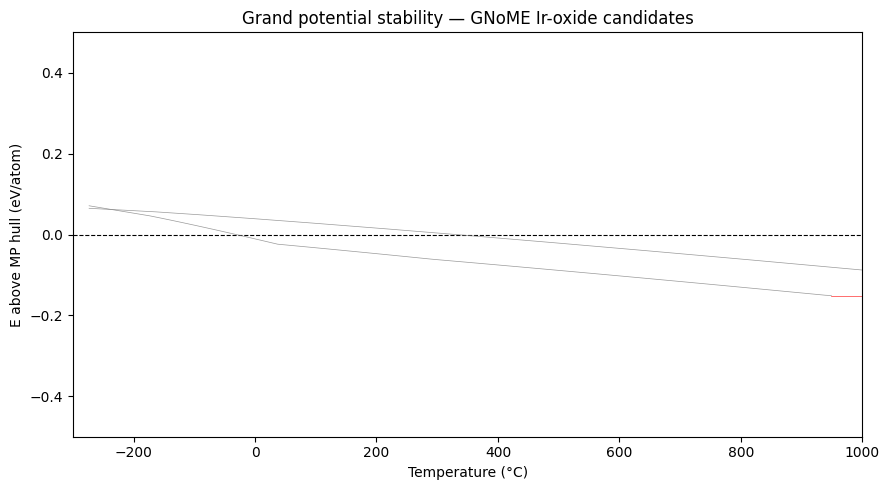

In [189]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('E above MP hull (eV/atom)')
ax.set_title('Grand potential stability — GNoME Ir-oxide candidates')

notabuls = []

# --- Plot filters ---
show_reds        = True   # False → skip entries where Si appears in any decomp product
show_stable_only = True   # True  → only show entries that dip below stable_threshold
stable_threshold = 0.0    # eV/atom
stable_T1        = 450      # °C — window start
stable_T2        = 550   # °C — window end (≈ 1300 K)

for (T_C, E_arr, decomp_list, formula) in data:
    N = len(E_arr)
    has_si = [any('Si' in f for f in d.keys()) for d in decomp_list]

    if not show_reds and any(has_si):
        continue

    if show_stable_only:
        if any(e > stable_threshold for t, e in zip(T_C, E_arr)
                if stable_T1 <= t <= stable_T2):
            continue

    i_s = 0
    for i in range(1, N):
        if has_si[i] != has_si[i_s]:
            color = 'red' if has_si[i_s] else 'gray'
            ax.plot(T_C[i_s:i + 1], E_arr[i_s:i + 1], '-', alpha=0.8, lw=0.5, color=color)
            i_s = i
    color = 'red' if has_si[i_s] else 'gray'
    ax.plot(T_C[i_s:], E_arr[i_s:], '-', alpha=0.8, lw=0.5, color=color)

    print(formula)

plt.ylim(-0.5, 0.5)
plt.xlim(-300, 1000)
plt.tight_layout()
plt.show()


### Notable entries — decomposition products

In [ ]:
fig, axes = plt.subplots(1, len(notabuls), figsize=(5 * len(notabuls), 4), sharey=True)
if len(notabuls) == 1:
    axes = [axes]

for ax, (idx, formula) in zip(axes, notabuls):
    row = df.iloc[idx]
    res = analyzer.compute_one(row['MaterialId'], return_decomp=True)

    plot_stability_decomp(res.T_values, res.E_above_hull, res.decomp, formula, ax=ax)
    if ax is not axes[0]:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()